<a href="https://colab.research.google.com/github/DilshanBotheju/CSACP_Project/blob/main/HomicidePatternRecognizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [126]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [127]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import folium
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [128]:
#Load relevant datasets
homicide_data_path = "/content/drive/MyDrive/DSGP/datasets/preprocessed_dataset.csv"
homicide_data = pd.read_csv(homicide_data_path, encoding = "latin-1")
homicide_data.head()

,City,State,Year,Month,Incident,Crime Type,Victim Sex,Victim Age,Victim Race,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
0,San Bernardino,California,2005,7,1,Murder or Manslaughter,Male,18,White,Male,0.0,White,Acquaintance,Handgun,1,0,Teen (13-19),NaN
1,Harris,Texas,2013,5,3,Murder or Manslaughter,Male,27,White,Male,0.0,White,Acquaintance,Firearm,0,0,Young Adult (20-29),NaN
2,St. Francis,Arkansas,2001,6,1,Murder or Manslaughter,Male,42,Black,Male,18.0,Black,Acquaintance,Handgun,0,0,Adult (30-49),Teen (13-19)
3,Pima,Arizona,1998,3,6,Murder or Manslaughter,Male,44,White,Male,0.0,White,Acquaintance,Handgun,0,0,Adult (30-49),NaN
4,Okanogan,Washington,1999,8,1,Murder or Manslaughter,Female,15,White,Male,20.0,White,Girlfriend,Rifle,0,0,Teen (13-19),Young Adult (20-29)


EDA (Exploratory Data Analysis)

<ipython-input-131-372c2f28047c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Crime Type", order=homicide_data["Crime Type"].value_counts().index, palette="coolwarm")


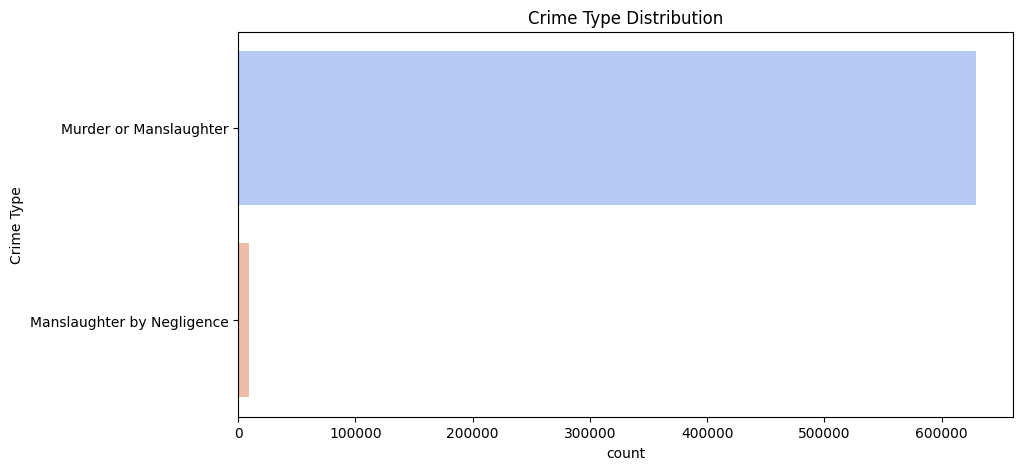

In [131]:
# Distribution of homicide crime types
plt.figure(figsize=(10,5))
sns.countplot(data=homicide_data, y="Crime Type", order=homicide_data["Crime Type"].value_counts().index, palette="coolwarm")
plt.title("Crime Type Distribution")
plt.show()

<ipython-input-132-b69b9ed5197d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=homicide_data, y="Weapon", order=homicide_data["Weapon"].value_counts().head(10).index, palette="magma")


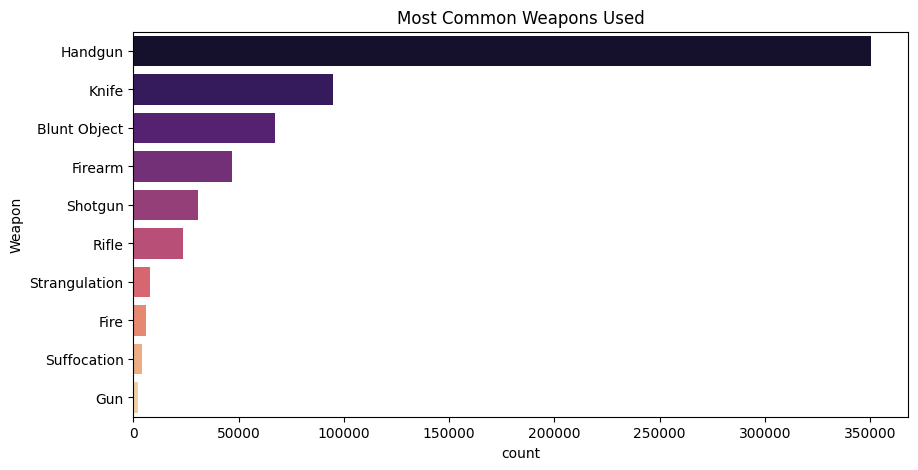

In [132]:
# Plotting most common weapons used
plt.figure(figsize=(10,5))
sns.countplot(data=homicide_data, y="Weapon", order=homicide_data["Weapon"].value_counts().head(10).index, palette="magma")
plt.title("Most Common Weapons Used")
plt.show()

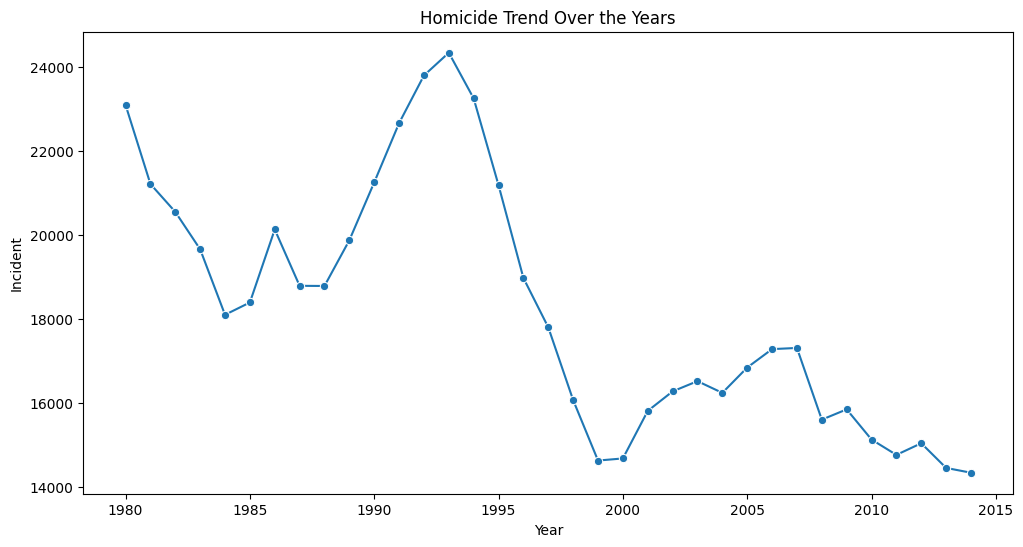

In [133]:
# Identify homicide trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(x="Year", y="Incident", data=homicide_data.groupby("Year")["Incident"].count().reset_index(), marker="o")
plt.title("Homicide Trend Over the Years")
plt.show()

In [134]:
# Drop unnecessary columns
homicide_data = homicide_data.drop(columns=["Perpetrator Age","Victim Age","Incident","Crime Type"])

In [135]:
# View data
homicide_data.head()

,City,State,Year,Month,Victim Sex,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
0,San Bernardino,California,2005,7,Male,White,Male,White,Acquaintance,Handgun,1,0,Teen (13-19),NaN
1,Harris,Texas,2013,5,Male,White,Male,White,Acquaintance,Firearm,0,0,Young Adult (20-29),NaN
2,St. Francis,Arkansas,2001,6,Male,Black,Male,Black,Acquaintance,Handgun,0,0,Adult (30-49),Teen (13-19)
3,Pima,Arizona,1998,3,Male,White,Male,White,Acquaintance,Handgun,0,0,Adult (30-49),NaN
4,Okanogan,Washington,1999,8,Female,White,Male,White,Girlfriend,Rifle,0,0,Teen (13-19),Young Adult (20-29)


In [136]:
# Check null values
homicide_data.isnull().sum()

,0
City,0
State,0
Year,0
Month,0
Victim Sex,0
Victim Race,0
Perpetrator Sex,0
Perpetrator Race,0
Relationship,0
Weapon,0


In [140]:
# Drop unnecessary columns
homicide_data = homicide_data.drop(columns=["Perpetrator Age Group"])

In [141]:
# Getting a sample percentage of data to preprocess
data_percentage = 1
homicide_data = homicide_data.sample(frac=data_percentage, random_state=42)

In [142]:
# Replacing NA with Unknown to identify null columns
homicide_data.replace( np.nan,"Unknown", inplace=True)

In [143]:
# View data
homicide_data.head()

,City,State,Year,Month,Victim Sex,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group
407513,Onondaga,New York,1997,6,Male,White,Male,Black,Stranger,Knife,0,0,Senior (50+)
73860,Harris,Texas,2008,1,Male,Black,Male,Black,Stranger,Handgun,0,0,Young Adult (20-29)
515055,Hamilton,Tennessee,2014,6,Male,Black,Male,White,Acquaintance,Handgun,0,0,Adult (30-49)
465830,District of Columbia,District of Columbia,2002,7,Female,White,Male,Black,Acquaintance,Handgun,0,0,Young Adult (20-29)
452418,San Diego,California,1984,10,Female,White,Female,White,Friend,Handgun,0,0,Young Adult (20-29)


In [144]:
# View dataset info
homicide_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 638454 entries, 407513 to 610804
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   City               638454 non-null  object
 1   State              638454 non-null  object
 2   Year               638454 non-null  int64 
 3   Month              638454 non-null  int64 
 4   Victim Sex         638454 non-null  object
 5   Victim Race        638454 non-null  object
 6   Perpetrator Sex    638454 non-null  object
 7   Perpetrator Race   638454 non-null  object
 8   Relationship       638454 non-null  object
 9   Weapon             638454 non-null  object
 10  Victim Count       638454 non-null  int64 
 11  Perpetrator Count  638454 non-null  int64 
 12  Victim Age Group   638454 non-null  object
dtypes: int64(4), object(9)
memory usage: 68.2+ MB


In [146]:
from sklearn.preprocessing import LabelEncoder


# Label encoding categorical features
categorical_cols = [ "City", "State","Victim Sex", "Victim Race","Perpetrator Sex", "Perpetrator Race", "Relationship", "Weapon","Victim Age Group"]
encoder_dict = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    homicide_data[col] = encoder.fit_transform(homicide_data[col])
    encoder_dict[col] = encoder



In [109]:
# Viewing the data
homicide_data.head()

,City,State,Year,Month,Crime Type,Victim Sex,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group
484984,87,20,1996,8,1,1,1,1,3,0,8,0,0,2,4
608445,539,30,2013,9,1,1,3,1,1,25,8,0,0,5,3
417612,1695,22,1997,11,1,1,1,1,3,0,6,0,0,5,4
372692,425,9,1995,12,1,1,3,1,1,20,0,0,0,1,0
402028,946,4,2002,11,1,1,3,1,3,25,8,0,0,3,3


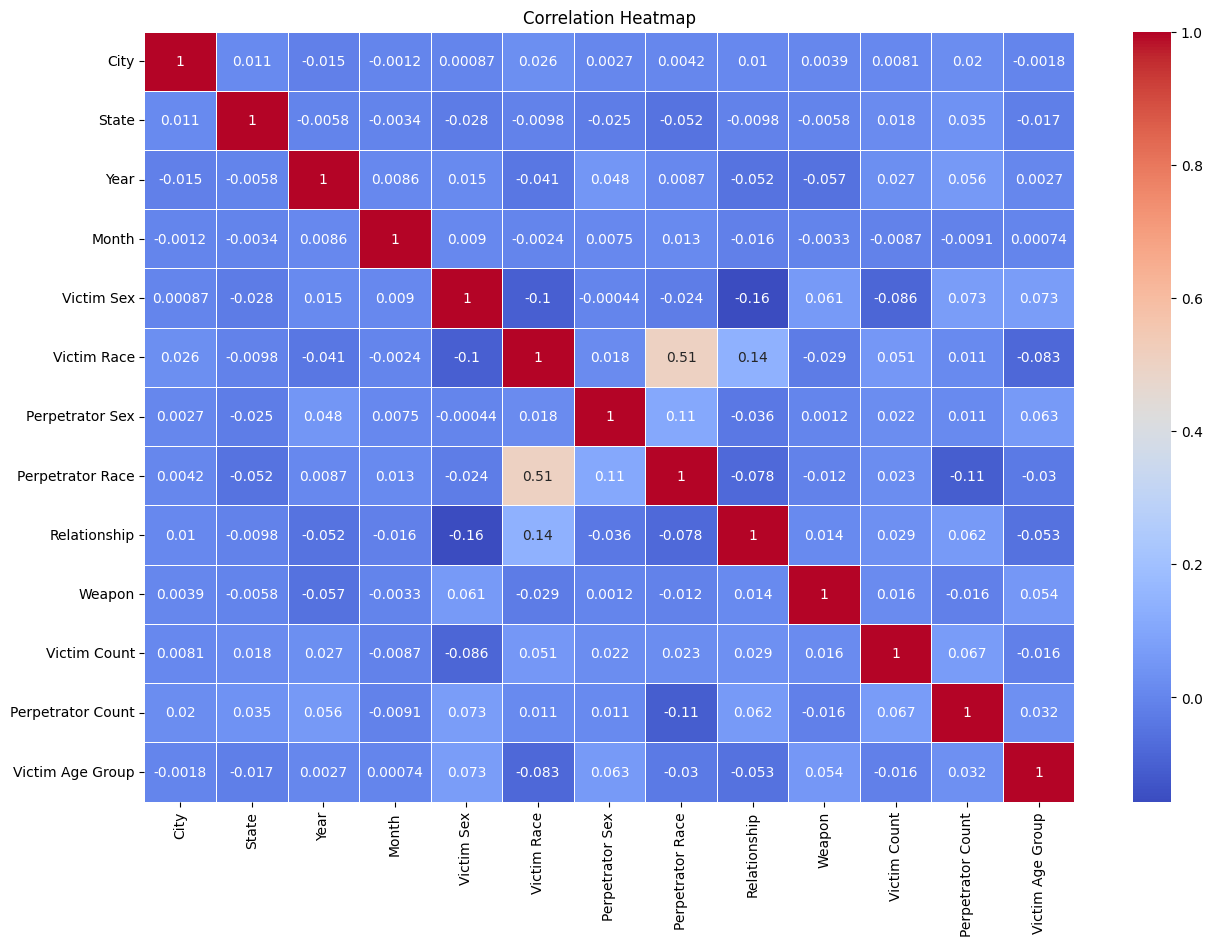

In [147]:
# Getting correlation matrix
correlation_matrix = homicide_data.corr()

# Plotting heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Model Building

In [148]:
# Select features
features = ['City', 'State', 'Year', 'Month', 'Victim Sex','Perpetrator Sex','Weapon', 'Victim Count', 'Perpetrator Count', 'Victim Age Group']

X = homicide_data[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

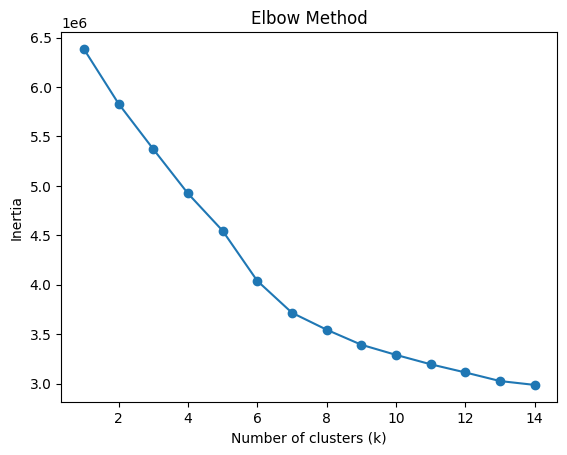

In [166]:
# Using elbow method to identify clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 15), inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [167]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(n_clusters=6, random_state=42)
kmeans.fit(X_scaled)

# Assign clusters to your data
homicide_data["Cluster"] = kmeans.labels_

In [168]:
homicide_data.head()

,City,State,Year,Month,Victim Sex,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Cluster,PCA1,PCA2
407513,1177,32,1997,6,1,3,1,1,25,9,0,0,2,4,0.321305,-0.188230
73860,705,43,2008,1,1,1,1,1,25,8,0,0,5,2,0.886134,0.617019
515055,684,42,2014,6,1,1,1,3,0,8,0,0,0,4,-0.297088,0.803177
465830,476,8,2002,7,0,3,1,1,0,8,0,0,5,4,-0.149362,0.107088
452418,1397,4,1984,10,0,3,0,3,13,8,0,0,5,3,-1.134617,-1.916261


In [169]:
print(homicide_data["Cluster"].value_counts())

Cluster
4    251429
2    211606
5     62869
3     47558
1     41965
0     23027
Name: count, dtype: int64


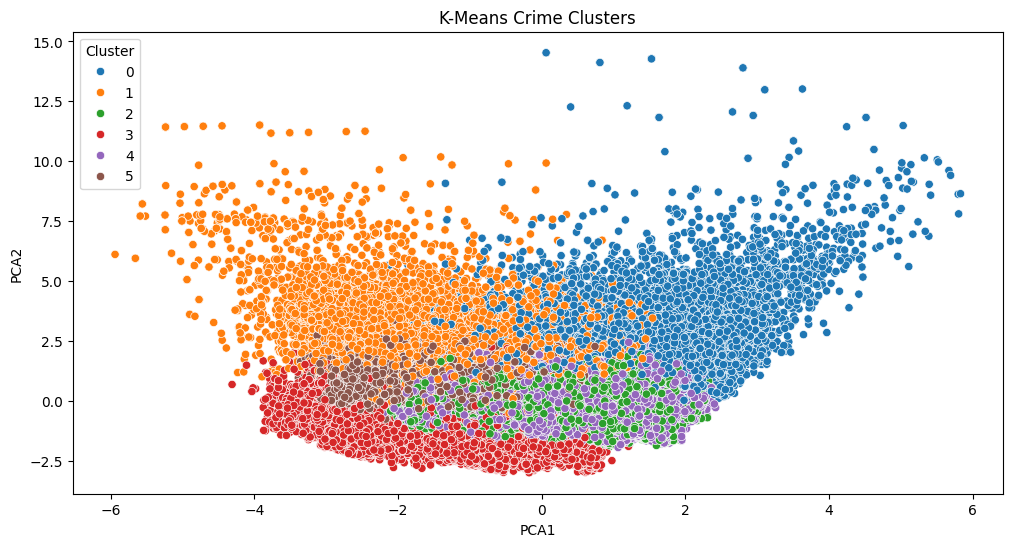

In [170]:
# Visualize with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
homicide_data['PCA1'] = X_pca[:, 0]
homicide_data['PCA2'] = X_pca[:, 1]

# Plot K-Means Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='Cluster', palette='tab10')
plt.title('K-Means Crime Clusters')
plt.show()

<ipython-input-158-2828eef811a9>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='tab10')


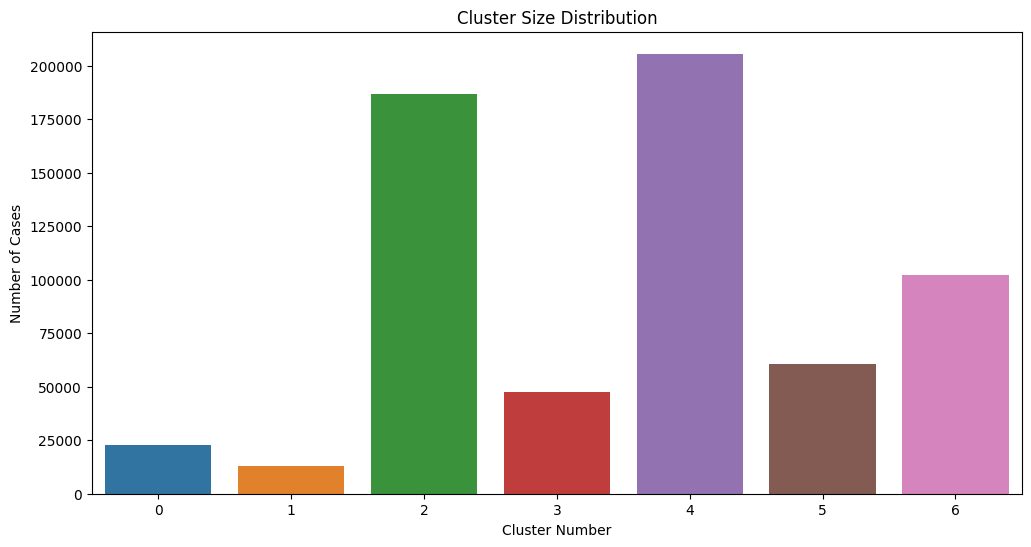

In [158]:
# Count the number of cases per cluster
cluster_counts = homicide_data['Cluster'].value_counts().sort_index()

# Bar chart of cluster sizes
plt.figure(figsize=(12, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='tab10')
plt.xlabel('Cluster Number')
plt.ylabel('Number of Cases')
plt.title('Cluster Size Distribution')
plt.show()


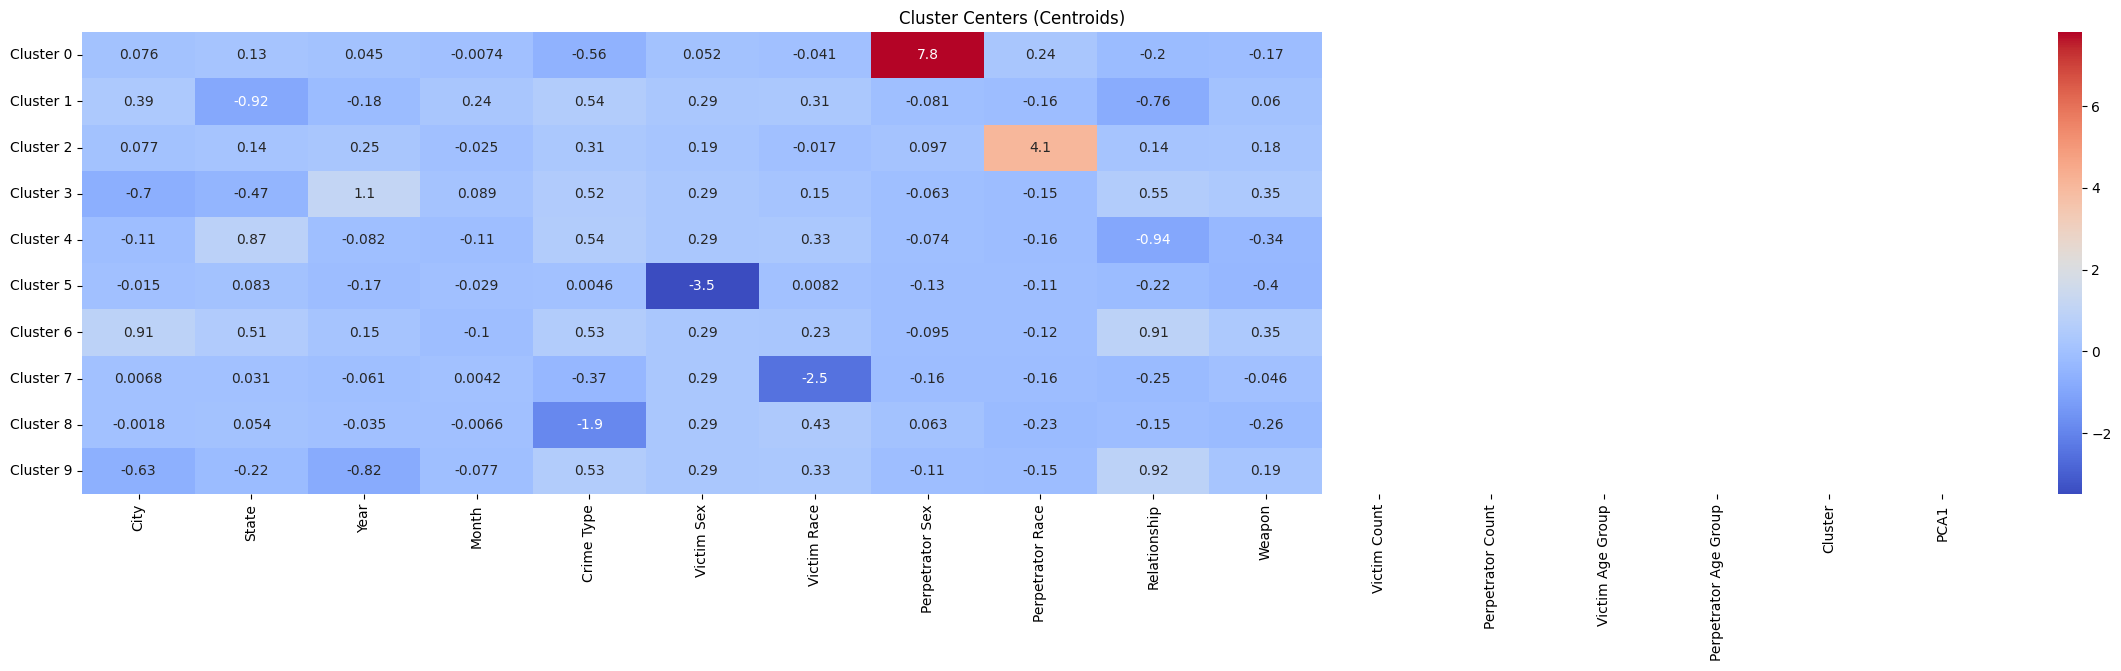

In [118]:
# You can also explore cluster centers (centroids)
centroids = kmeans.cluster_centers_

# Plot centroids to understand cluster centers
plt.figure(figsize=(30, 6))
sns.heatmap(centroids, annot=True, cmap='coolwarm', xticklabels=homicide_data.columns[:-1], yticklabels=[f'Cluster {i}' for i in range(kmeans.n_clusters)])
plt.title("Cluster Centers (Centroids)")
plt.show()

,City,State,Year,Month,Crime Type,Victim Sex,Victim Race,Perpetrator Sex,Perpetrator Race,Relationship,Weapon,Victim Count,Perpetrator Count,Victim Age Group,Perpetrator Age Group,PCA1,PCA2
Cluster,,,,,,,,,,,,,,,,,
0,208726.494916,218.397282,105.914646,11.723369,0.016075,0.247734,1.031979,0.059315,0.959395,117.149219,7.226237,3.830409,0.762693,3.341481,4.457189,1.425538,5.136855
1,159485.880491,49.945095,80.348233,11.604661,0.012230,0.000012,1.050401,0.000000,0.844605,104.270213,2.097069,0.090598,0.082184,1.283410,3.168066,0.428531,0.410361
2,212968.313951,242.223662,94.471006,11.544324,0.006630,0.089816,1.060506,0.025132,1.031609,140.293731,8.286185,0.234130,0.972254,4.323477,2.797970,0.940836,1.359712
3,126181.047933,151.993513,24.392630,11.299270,0.016775,0.009411,0.987386,0.000000,0.871442,81.251673,1.561654,0.104649,0.087131,3.078329,1.771811,0.387623,0.295314
4,188254.301507,62.811510,92.393894,11.636519,0.012057,0.000000,1.025039,0.000000,0.916245,98.465458,2.210229,0.103442,0.086265,0.856224,3.899016,0.424429,0.471638
5,223334.268250,231.564594,101.188863,11.622062,0.028999,0.173080,1.020126,0.000000,1.018733,69.055158,10.636234,0.066260,0.146921,3.754271,4.915927,1.088249,0.862628
6,68710.285691,139.453926,79.121645,11.484875,0.011267,0.005080,0.958505,0.000000,0.969334,87.665038,1.702041,0.083378,0.104366,1.177990,1.941025,0.298755,0.437625
7,215558.530891,224.904558,96.456923,11.449715,0.012494,0.235664,0.959908,0.000000,0.860999,101.121932,0.090983,0.045164,0.084912,3.235796,3.964566,0.985030,0.451681
8,218353.596388,230.260264,96.751742,11.830766,0.013140,0.000000,1.013083,0.000000,0.898811,118.300327,3.277432,0.186299,0.049967,4.115904,3.942922,0.861480,0.601753


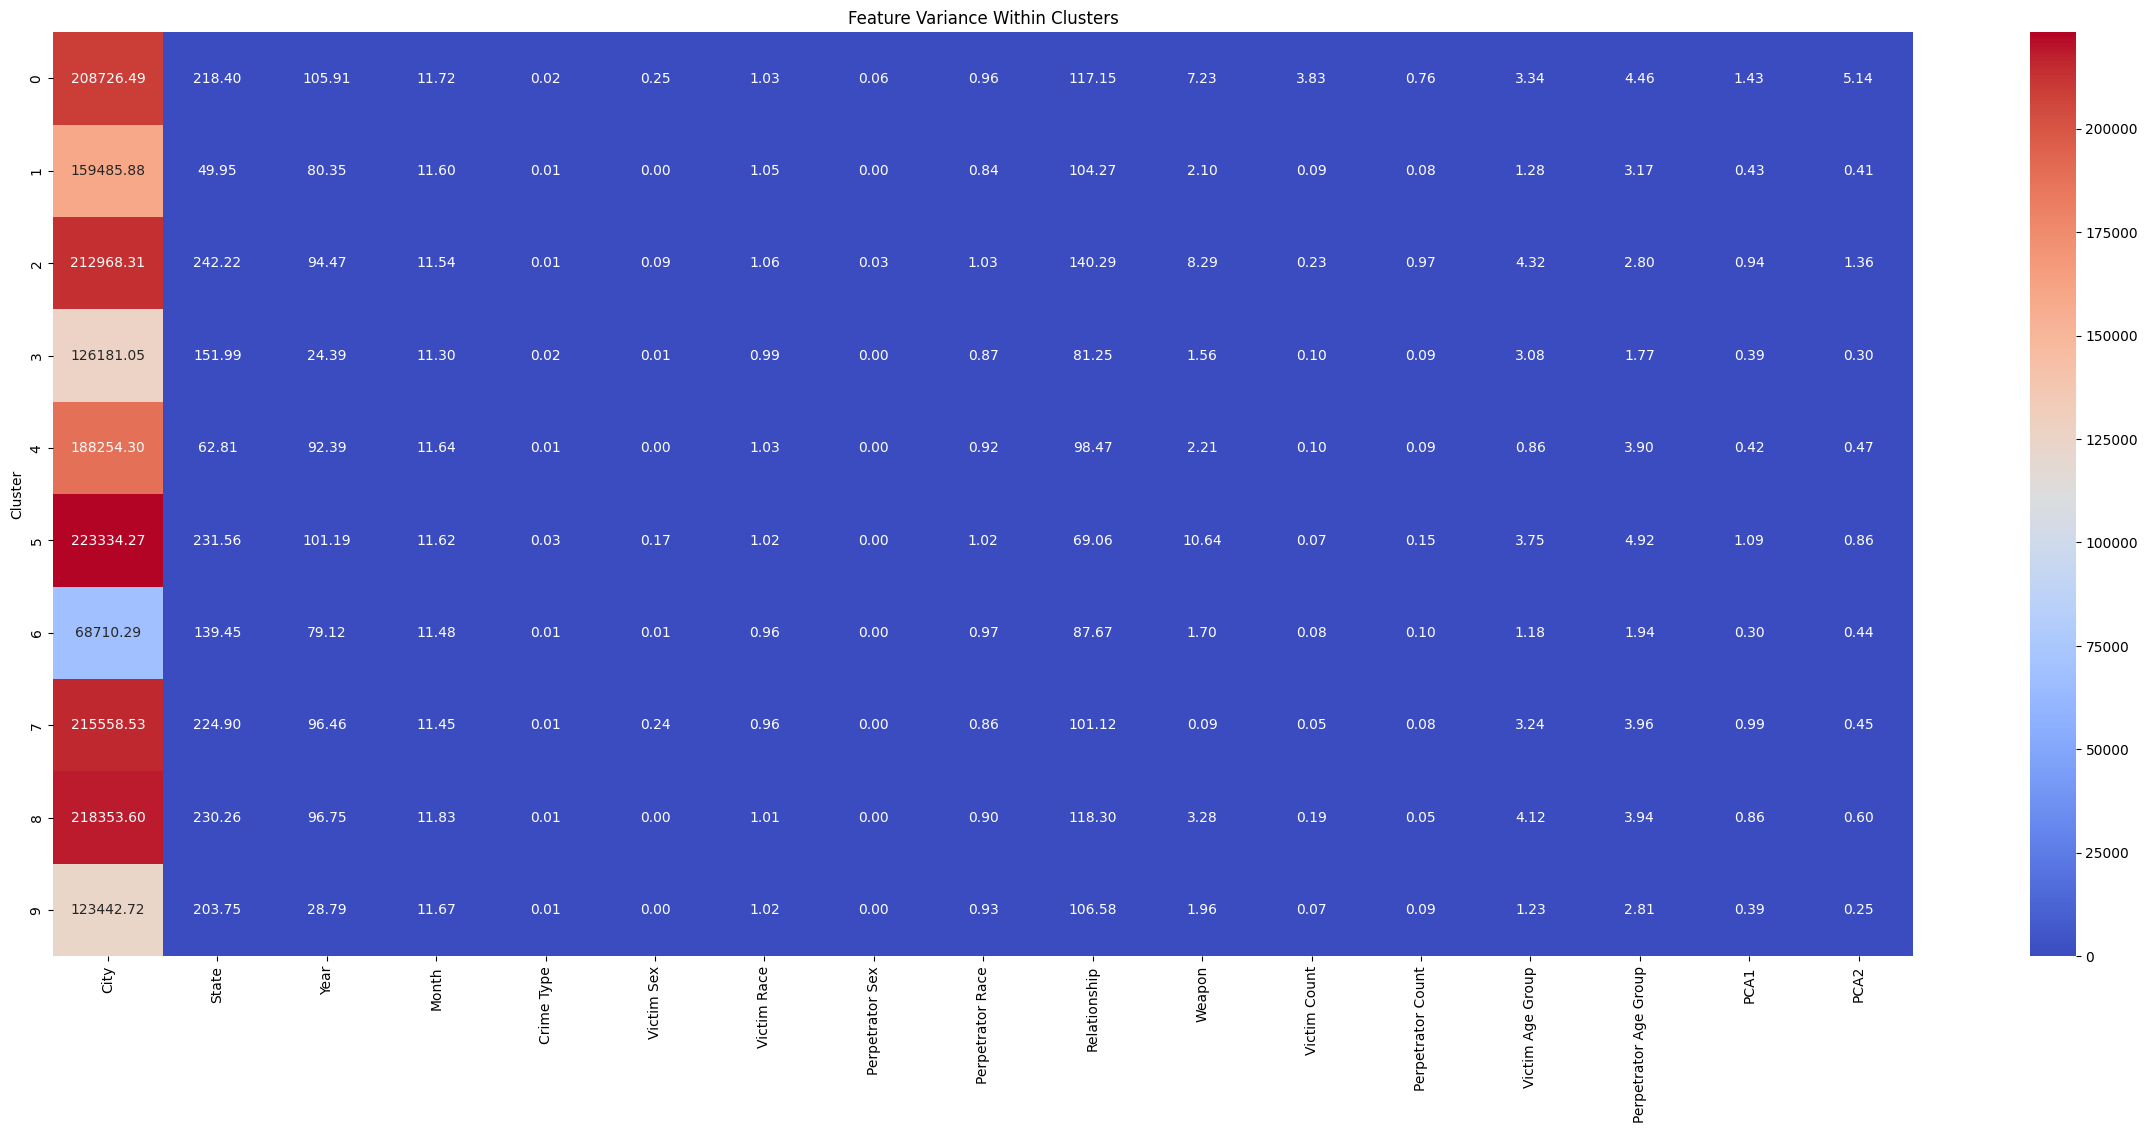

In [119]:
# Calculate feature variance within clusters
feature_variance = homicide_data.groupby('Cluster').var()
display(feature_variance)

# Visualize feature variance across clusters
plt.figure(figsize=(30, 12))
sns.heatmap(feature_variance, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title("Feature Variance Within Clusters")
plt.show()


In [122]:
low_variance_threshold = 0.1 # You can adjust this value

for cluster in feature_variance.index:
    cluster_variance = feature_variance.loc[cluster]
    low_variance_features = cluster_variance[cluster_variance < low_variance_threshold]

    print(f"Cluster {cluster} - Low variance features:")
    print(low_variance_features)
    print("---")


Cluster 0 - Low variance features:
Crime Type         0.016075
Perpetrator Sex    0.059315
Name: 0, dtype: float64
---
Cluster 1 - Low variance features:
Crime Type           0.012230
Victim Sex           0.000012
Perpetrator Sex      0.000000
Victim Count         0.090598
Perpetrator Count    0.082184
Name: 1, dtype: float64
---
Cluster 2 - Low variance features:
Crime Type         0.006630
Victim Sex         0.089816
Perpetrator Sex    0.025132
Name: 2, dtype: float64
---
Cluster 3 - Low variance features:
Crime Type           0.016775
Victim Sex           0.009411
Perpetrator Sex      0.000000
Perpetrator Count    0.087131
Name: 3, dtype: float64
---
Cluster 4 - Low variance features:
Crime Type           0.012057
Victim Sex           0.000000
Perpetrator Sex      0.000000
Perpetrator Count    0.086265
Name: 4, dtype: float64
---
Cluster 5 - Low variance features:
Crime Type         0.028999
Perpetrator Sex    0.000000
Victim Count       0.066260
Name: 5, dtype: float64
---
Cluster 

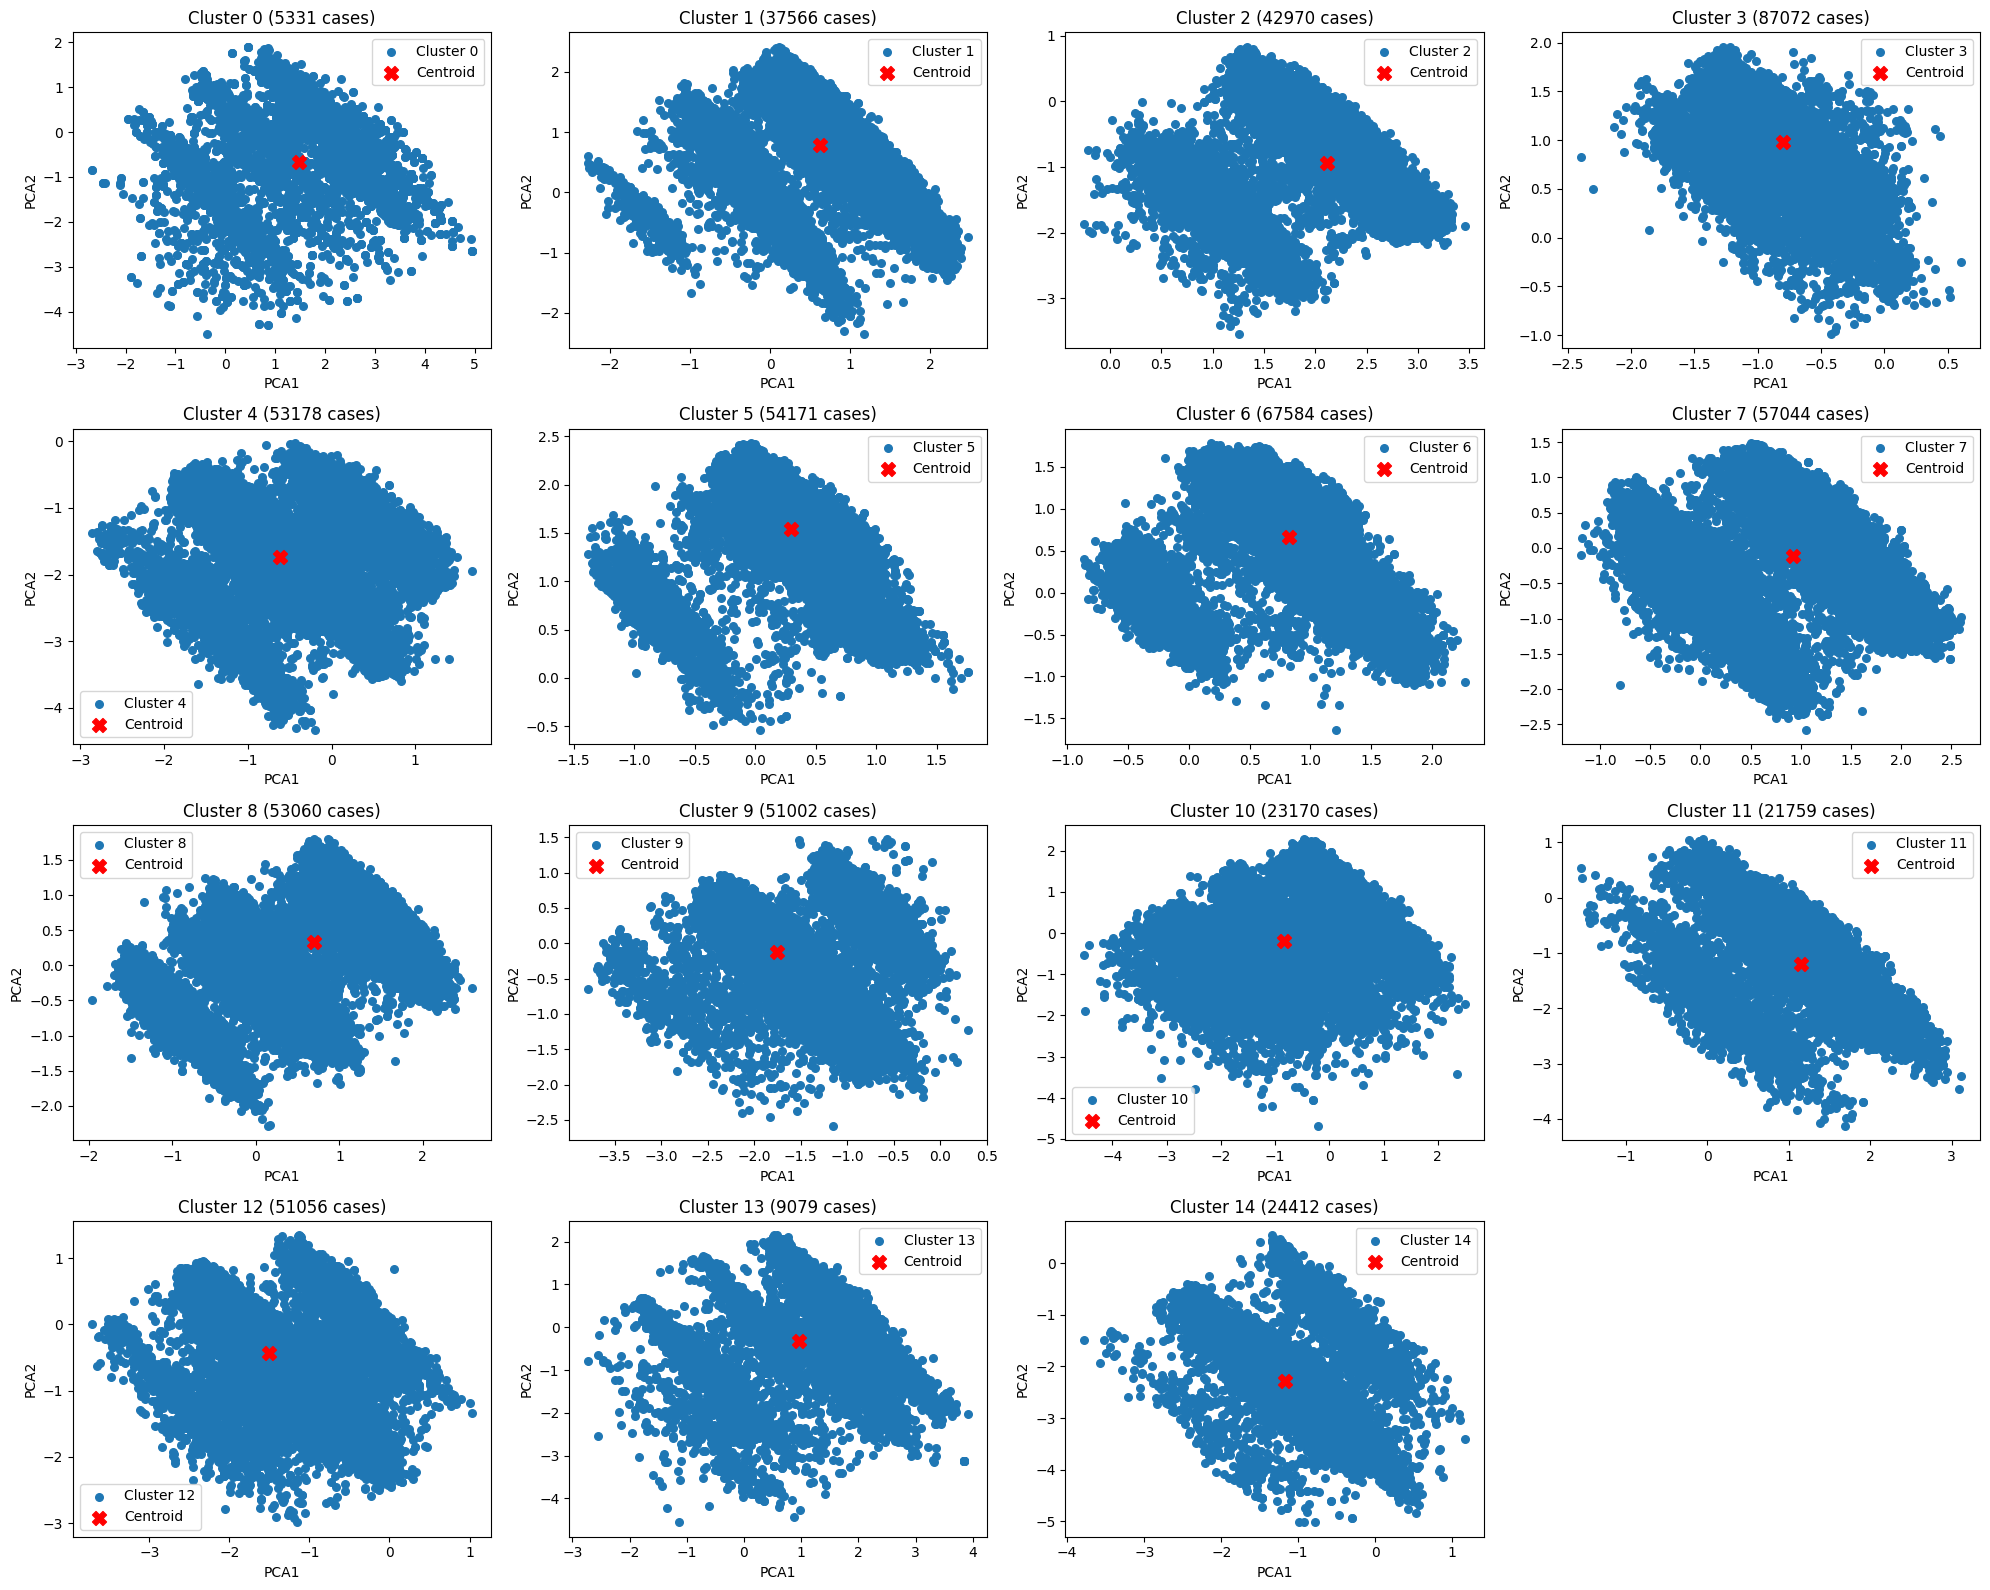

In [24]:
unique_clusters = homicide_data['Cluster'].unique()
num_clusters = len(unique_clusters)

# Create subplots (4x4 grid to fit 14 clusters, leaving 2 empty)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()

for i, cluster in enumerate(sorted(unique_clusters)):
    ax = axes[i]
    cluster_data = homicide_data[homicide_data['Cluster'] == cluster]

    # Scatter plot of the cluster points
    ax.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster}', s=30)

    # Calculate and plot the centroid (mean of PCA1 and PCA2)
    centroid_x = cluster_data['PCA1'].mean()
    centroid_y = cluster_data['PCA2'].mean()
    ax.scatter(centroid_x, centroid_y, color='red', marker='X', s=100, label='Centroid')

    count = len(cluster_data)
    ax.set_title(f'Cluster {cluster} ({count} cases)')
    ax.set_xlabel('PCA1')
    ax.set_ylabel('PCA2')
    ax.legend()

# Hide unused subplots (since 16 subplots but only 14 clusters)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [74]:
centroids = kmeans.cluster_centers_

# Apply PCA to reduce centroids' coordinates to 2D
pca = PCA(n_components=2)
centroids_2d = pca.fit_transform(centroids)  # Transform centroids into 2D space

# Print the 2D coordinates of the centroids
for i, centroid in enumerate(centroids_2d):
    print(f"Centroid of Cluster {i}: {centroid}")

Centroid of Cluster 0: [ 7.10685077 -0.08394062]
Centroid of Cluster 1: [-0.82153563 -0.30227965]
Centroid of Cluster 2: [-0.64170292  3.63129558]
Centroid of Cluster 3: [-0.84969311 -0.06928447]
Centroid of Cluster 4: [-0.77269309 -0.30666944]
Centroid of Cluster 5: [-0.95280536 -1.63251933]
Centroid of Cluster 6: [-0.8619974  -0.02806607]
Centroid of Cluster 7: [-0.84160236 -0.42565472]
Centroid of Cluster 8: [-0.45145644 -0.58529611]
Centroid of Cluster 9: [-0.91336446 -0.19758517]


Advanced

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


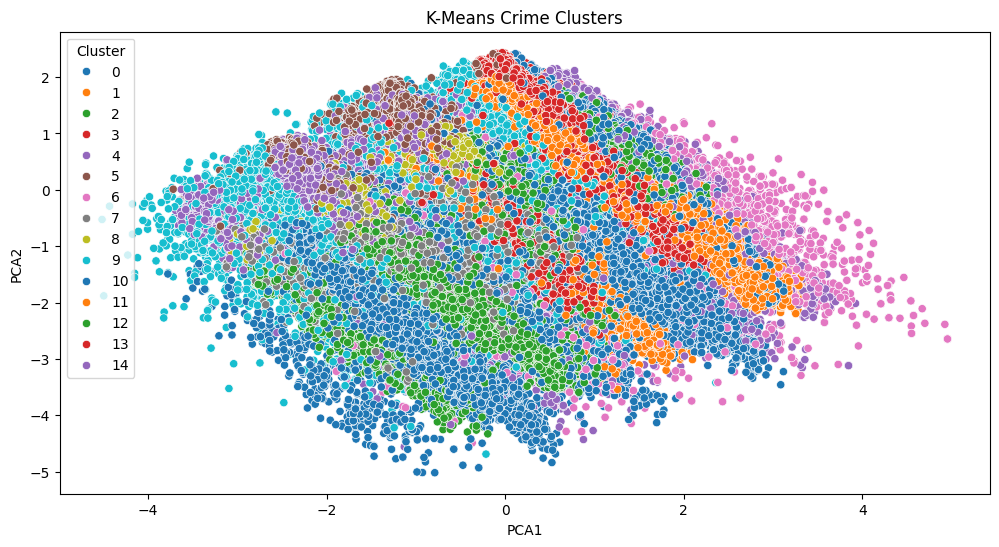

In [23]:
# K-Means Clustering
kmeans = KMeans(n_clusters=15, random_state=42)
homicide_data['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
homicide_data['PCA1'] = X_pca[:, 0]
homicide_data['PCA2'] = X_pca[:, 1]

# Plot K-Means Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='Cluster', palette='tab10')
plt.title('K-Means Crime Clusters')
plt.show()

In [24]:
homicide_data['Cluster'].value_counts()

,count
Cluster,
13,64649
1,61212
10,58651
4,55459
8,52187
3,49601
5,48000
2,46982
12,46345


In [25]:
top_clusters = homicide_data['Cluster'].value_counts().head(2).index.tolist()
homicide_data['Serial_Crime'] = homicide_data['Cluster'].apply(lambda x: 1 if x in top_clusters else 0)

In [26]:
# Value count for serial crime
homicide_data['Serial_Crime'].value_counts()

,count
Serial_Crime,
0,512593
1,125861


In [28]:
# Use features and target
y = homicide_data['Serial_Crime']

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [ ]:
# Build KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict on training data
y_train_pred = knn.predict(X_train)

# Predict on test data
y_test_pred = knn.predict(X_test)

# Accuracy report
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nTesting Accuracy:", accuracy_score(y_test, y_test_pred))

# Detailed classification report
print("\nClassification Report (Test Data):\n")
print(classification_report(y_test, y_test_pred))


Training Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    358782
           1       1.00      1.00      1.00     88135

    accuracy                           1.00    446917
   macro avg       1.00      1.00      1.00    446917
weighted avg       1.00      1.00      1.00    446917


Testing Accuracy: 0.997253794306061
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    153811
           1       0.99      0.99      0.99     37726

    accuracy                           1.00    191537
   macro avg       1.00      0.99      1.00    191537
weighted avg       1.00      1.00      1.00    191537



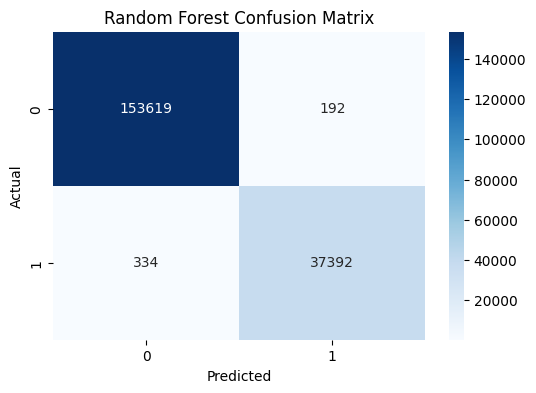

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Accuracy Reports
print("\nTraining Accuracy:", accuracy_score(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))

print("\nTesting Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=2, min_samples=5)
homicide_data['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Plot DBSCAN Clusters
plt.figure(figsize=(12, 6))
sns.scatterplot(data=homicide_data, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette='tab10')
plt.title('DBSCAN Crime Clusters')
plt.show()

NameError: name 'DBSCAN' is not defined

In [ ]:
# Check cluster composition
for cluster in homicide_data['KMeans_Cluster'].unique():
    print(f"\nCluster {cluster} sample crimes:")
    print(homicide_data[homicide_data['KMeans_Cluster'] == cluster][features].head())